<a href="https://colab.research.google.com/github/GunaPalanivel/Praxis/blob/main/praxis_grpo_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Open in Colab:** use the badge at the top of this notebook.


# Praxis GRPO — Judge evidence (`train_praxis_grpo.py` + **HF TRL / Unsloth**)

**Easy run (judges):** **Runtime → Change runtime type → GPU (T4 or better) → Save**, then **Runtime → Run all**.  
First run downloads deps via `uv` (~10–25 min). You get **`metrics.csv` + `reward_curve.png` + `loss_curve.png`** with **real GRPO training loss** from `trl.GRPOTrainer` (same stack as [HF Jobs](https://huggingface.co/docs/huggingface_hub/main/en/guides/hf_jobs)).

| Runtime | What runs | Meets “TRL + evidence plots” |
| ------- | ---------- | ------------------------------ |
| **GPU (default)** | `uv run train_praxis_grpo.py` **without** `--smoke`: **2** optimizer steps, `--dataset-repeats 1`, one task, `max_turns=45` (short rollouts) | **Yes** — Unsloth 4-bit + LoRA + TRL GRPO, live Space reward |
| **CPU only** | Same script with `--smoke` (HTTP env loop, **no** `GRPOTrainer`) | **Partially** — proves live Space + CSV/plots; enable GPU for TRL |

**Long production run (optional):** set env **`PRAXIS_COLAB_FULL=1`** (GPU) before the train cell for `--steps 200` and all four tasks (`scripts/submit_hf_grpo_job.py` parity). Expect long runtime + heavy `uv` resolve.

**Reward contract:** full TRL path uses `reward_func` → HTTPS `POST /reset` / `POST /step` on **`https://gp5901-praxis.hf.space`**. Smoke uses fixed fallback commands per step.

**Avoid HTTP 400 on `/step`:** Old Colab snippets that call `run_episode(task, logits, ...)` often omit `session_id` or send a blank `command`. Run the **optional HTTP helper** cell (after the health check) before any pasted legacy loop so `/step` receives a non-empty `command` from the server's `available_commands` plus `session_id` in the JSON body (and `X-Session-Id` header).

**Outputs:** `checkpoints/praxis-grpo/metrics.csv` and `run_manifest.json` → copied to `/content/`. Plots read **reward** and **loss** from CSV (TRL loss is real; smoke loss is `max(0, 1-reward)`).

**Trackio (optional):** Colab secrets **`HF_TOKEN`** + **`TRACKIO_SPACE_ID=gp5901/trackio`**, and remove **`--no-wandb`** from the train cell if you want Hub dashboard sync.

## Data flow (canonical training)

```mermaid
flowchart TB
    subgraph Trainer[train_praxis_grpo.py]
        GR[GRPOTrainer TRL]
        RF[reward_func completions]
    end
    subgraph Remote[Hugging Face Space]
        API[FastAPI /reset /step /state]
        ENV[PraxisEnvironment + scenarios]
        RUB[Reward engine]
    end
    GR --> RF
    RF -->|HTTPS JSON| API
    API --> ENV
    ENV --> RUB
    RUB -->|reward info| RF
```

The **CPU** path skips **GRPOTrainer** (`--smoke`) but still hits the live Space for real HTTP rewards. The **GPU** path matches the diagram (TRL + `reward_func` + Space).


In [11]:
# Install uv (PEP 723 deps for train_praxis_grpo.py) + plotting
%pip install -q uv matplotlib pandas


In [13]:
# Clone Praxis (same layout HF Jobs checks out at PRAXIS_COMMIT)
import os
import shutil
import subprocess
import sys
from pathlib import Path

REPO = Path("/content/Praxis")
if REPO.exists():
    shutil.rmtree(REPO, ignore_errors=True)
subprocess.run(
    ["git", "clone", "--depth", "1", "https://github.com/GunaPalanivel/Praxis.git", str(REPO)],
    check=True,
)
os.chdir(REPO)
print("Repo:", REPO.resolve())
print("Python:", sys.executable)


CalledProcessError: Command '['git', 'clone', '--depth', '1', 'https://github.com/GunaPalanivel/Praxis.git', '/content/Praxis']' returned non-zero exit status 128.

In [ ]:
# Defaults: GPU → real TRL+Unsloth GRPO (tiny run). CPU → smoke only.
import os

PRAXIS_BASE_URL = os.environ.get("PRAXIS_URL", "https://gp5901-praxis.hf.space")
TASKS_ALL = "single-service-alert,ambiguous-incident,cascading-failure,memory-leak"
SEED = int(os.environ.get("PRAXIS_SEED", "2026"))
try:
    import torch

    HAS_GPU = bool(torch.cuda.is_available())
except Exception:
    HAS_GPU = False
FORCE_SMOKE = os.environ.get("PRAXIS_COLAB_FORCE_SMOKE", "").lower() in ("1", "true", "yes")
FULL_RUN = os.environ.get("PRAXIS_COLAB_FULL", "").lower() in ("1", "true", "yes")
USE_TRL = HAS_GPU and not FORCE_SMOKE
print("PRAXIS_BASE_URL:", PRAXIS_BASE_URL)
print("HAS_GPU:", HAS_GPU, "| USE_TRL_GRPO:", USE_TRL, "| PRAXIS_COLAB_FULL:", FULL_RUN)
if not HAS_GPU:
    print("Tip: Runtime → Change runtime type → GPU, then Run all, for HF TRL + Unsloth evidence.")


In [ ]:
# Health check against the live Space (same URL the trainer uses)
import requests

r = requests.get(f"{PRAXIS_BASE_URL.rstrip('/')}/health", timeout=30)
r.raise_for_status()
print("Space health:", r.json())
print("Space is live.")


### Optional: HTTP `run_episode` (legacy pasted loops)

Run this cell if you still have an old **numpy / requests** GRPO demo that calls `run_episode(task, logits, ...)`. The trainer cell below does **not** need this.


In [ ]:
# Safe rollout vs live Space (session_id in JSON + header; commands from /reset)
import time

import numpy as np
import requests


def _softmax(logits):
    x = np.asarray(logits, dtype=np.float64).reshape(-1)
    if x.size == 0:
        x = np.zeros(1, dtype=np.float64)
    x = x - np.max(x)
    e = np.exp(x)
    return e / (np.sum(e) + 1e-12)


def run_episode(task, logits, max_steps=10, delay=0.0):
    """One episode: /reset then /step until done or max_steps.
    Uses ``available_commands`` from the reset payload so ``command`` is always valid.
    Returns (rewards, chosen_idxs, trace)."""
    base = PRAXIS_BASE_URL.rstrip('/')
    r = requests.post(f"{base}/reset", json={"task_name": str(task)}, timeout=60)
    r.raise_for_status()
    data = r.json()
    sid = str(data.get("session_id") or "").strip()
    if not sid:
        raise RuntimeError("reset missing session_id; keys=" + repr(list(data.keys())))
    obs = data.get("observation", data)
    pool = [
        str(c).strip()
        for c in (obs.get("available_commands") or [])
        if str(c).strip()
    ]
    if not pool:
        raise RuntimeError("reset returned no non-empty available_commands")
    n = len(pool)
    lg = np.asarray(logits, dtype=np.float64).reshape(-1)
    if lg.size != n:
        lg = np.zeros(n, dtype=np.float64)
    headers = {"x-session-id": sid}
    rewards, chosen_idxs, trace = [], [], []
    for _ in range(int(max_steps)):
        probs = _softmax(lg)
        idx = int(np.random.choice(n, p=probs))
        command = pool[idx]
        if not command:
            continue
        payload = {"command": command, "session_id": sid}
        rr = requests.post(f"{base}/step", json=payload, headers=headers, timeout=60)
        if rr.status_code >= 400:
            raise RuntimeError(
                f"/step {rr.status_code}: {rr.text[:400]!r} payload={payload!r}"
            )
        out = rr.json()
        rewards.append(float(out.get('reward', 0.0)))
        chosen_idxs.append(idx)
        trace.append(out)
        if delay and float(delay) > 0:
            time.sleep(float(delay))
        if bool(out.get("done")):
            break
    return rewards, chosen_idxs, trace

print("Defined run_episode(task, logits, max_steps=..., delay=...).")


In [6]:
# Run canonical trainer via uv (PEP 723: trl, unsloth, transformers, …)
import os
import shutil
import subprocess
import sys
from pathlib import Path

repo = Path.cwd()
trainer = repo / "train_praxis_grpo.py"
assert trainer.is_file(), f"Missing {trainer} — run clone cell first"

env = os.environ.copy()
env["PRAXIS_URL"] = PRAXIS_BASE_URL

common_tail = [
    "--learning-rate",
    "1e-4",
    "--group-size",
    "8",
    "--model",
    "qwen-7b",
    "--base-url",
    PRAXIS_BASE_URL,
    "--seed",
    str(SEED),
    "--no-wandb",
]

if USE_TRL:
    if FULL_RUN:
        cmd = [
            "uv",
            "run",
            str(trainer),
            "--steps",
            "200",
            "--max-turns",
            "150",
            "--tasks",
            TASKS_ALL,
            *common_tail,
        ]
    else:
        # Minimal real GRPOTrainer run (judges: TRL + Unsloth + live reward)
        cmd = [
            "uv",
            "run",
            str(trainer),
            "--steps",
            "2",
            "--dataset-repeats",
            "1",
            "--tasks",
            "single-service-alert",
            "--max-turns",
            "45",
            *common_tail,
        ]
else:
    cmd = [
        "uv",
        "run",
        str(trainer),
        "--smoke",
        "--smoke-episodes",
        "2",
        "--steps",
        "25",
        "--tasks",
        TASKS_ALL,
        *common_tail,
    ]

print("$", " ".join(cmd))
rc = subprocess.run(cmd, cwd=str(repo), env=env).returncode
if rc != 0:
    raise SystemExit(f"train_praxis_grpo.py exited {rc}")
ck = repo / "checkpoints" / "praxis-grpo"
for name in ("metrics.csv", "run_manifest.json"):
    p = ck / name
    if p.is_file():
        dest = Path("/content") / name
        shutil.copy(p, dest)
        print("Copied to", dest)


$ uv run /content/Praxis/train_praxis_grpo.py --smoke --smoke-episodes 2 --steps 25 --tasks single-service-alert,ambiguous-incident,cascading-failure,memory-leak --learning-rate 1e-4 --group-size 8 --model qwen-7b --base-url https://gp5901-praxis.hf.space --seed 2026 --no-wandb
Copied to /content/metrics.csv
Copied to /content/run_manifest.json


In [7]:
# Optional: copy full checkpoint dir listing for judges
import json
from pathlib import Path

ck = Path("/content/Praxis/checkpoints/praxis-grpo")
if (ck / "run_manifest.json").is_file():
    print(json.dumps(json.loads((ck / "run_manifest.json").read_text()), indent=2)[:4000])
else:
    print("No run_manifest.json yet — re-run train cell.")


{
  "created_at": "2026-04-26T10:57:14.658864+00:00",
  "run_name": "praxis-smoke-20260426-105710",
  "model": "Qwen/Qwen2.5-7B-Instruct",
  "learning_rate": 0.0001,
  "steps": 25,
  "smoke_episodes": 2,
  "tasks": [
    "single-service-alert",
    "ambiguous-incident",
    "cascading-failure",
    "memory-leak"
  ],
  "num_generations": 8,
  "max_turns": 150,
  "seed": 2026,
  "smoke": true,
  "wandb_url": null,
  "trackio_url": null,
  "hub_model_id": null,
  "summary": {
    "single-service-alert": {
      "steps_observed": 8,
      "mean_reward": 0.17583333333333334
    },
    "ambiguous-incident": {
      "steps_observed": 2,
      "mean_reward": 0.01
    },
    "cascading-failure": {
      "steps_observed": 2,
      "mean_reward": 0.01
    },
    "memory-leak": {
      "steps_observed": 2,
      "mean_reward": 0.01
    }
  }
}


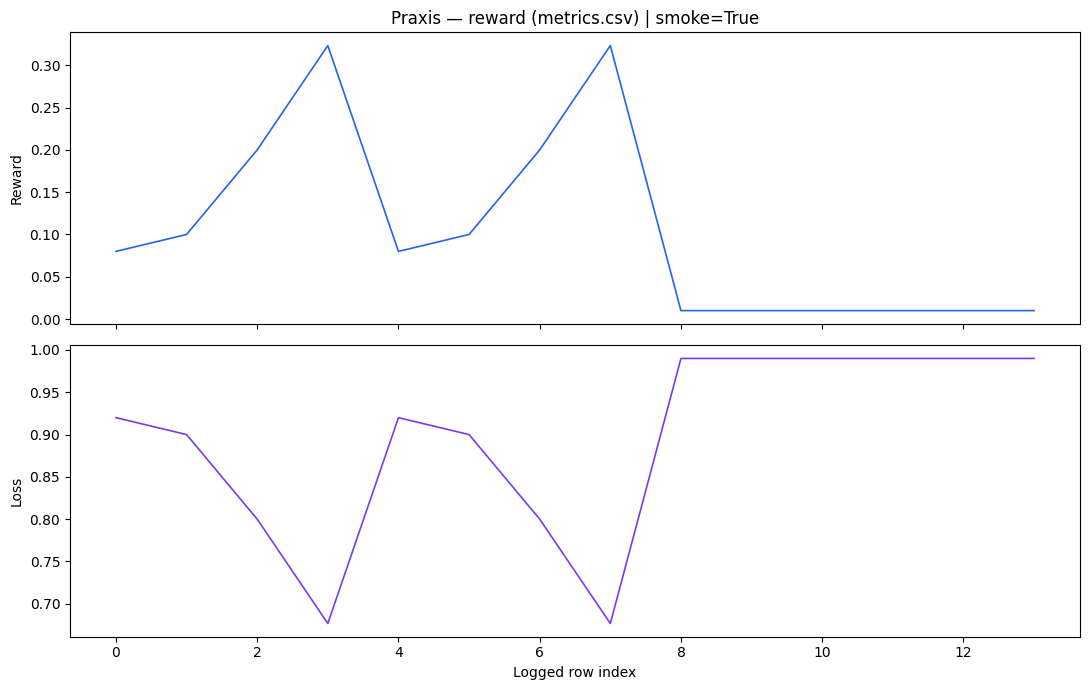

Saved /content/reward_curve.png and /content/loss_curve.png


In [8]:
# Evidence plots from real metrics.csv (reward + loss)
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

csv_path = Path("/content/Praxis/checkpoints/praxis-grpo/metrics.csv")
if not csv_path.is_file():
    csv_path = Path("/content/metrics.csv")
df = pd.read_csv(csv_path)
df["row"] = range(len(df))
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax0.plot(df["row"], pd.to_numeric(df["reward"], errors="coerce"), color="#2563eb", lw=1.2)
ax0.set_ylabel("Reward")
title = "Praxis — reward (metrics.csv)"
try:
    import json

    mf = Path("/content/Praxis/checkpoints/praxis-grpo/run_manifest.json")
    if mf.is_file():
        meta = json.loads(mf.read_text(encoding="utf-8"))
        title += " | smoke=" + str(meta.get("smoke"))
except Exception:
    pass
ax0.set_title(title)
ax1.plot(df["row"], pd.to_numeric(df["loss"], errors="coerce"), color="#7c3aed", lw=1.2)
ax1.set_ylabel("Loss")
ax1.set_xlabel("Logged row index")
plt.tight_layout()
plt.savefig("/content/reward_curve.png", dpi=150, bbox_inches="tight")
plt.savefig("/content/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved /content/reward_curve.png and /content/loss_curve.png")


In [9]:
# Summary from run_manifest.json (mean reward per task in smoke)
import json
from pathlib import Path

p = Path("/content/Praxis/checkpoints/praxis-grpo/run_manifest.json")
if not p.is_file():
    p = Path("/content/run_manifest.json")
if not p.is_file():
    print("No manifest found.")
else:
    m = json.loads(p.read_text(encoding="utf-8"))
    summ = m.get("summary", {})
    print("Run:", m.get("run_name"), "| smoke:", m.get("smoke"), "| steps arg:", m.get("steps"))
    print(f"{'Task':<28} {'mean_reward':>12}")
    for task, row in sorted(summ.items()):
        mr = row.get("mean_reward", 0.0)
        print(f"{task:<28} {float(mr):12.4f}")


Run: praxis-smoke-20260426-105710 | smoke: True | steps arg: 25
Task                          mean_reward
ambiguous-incident                 0.0100
cascading-failure                  0.0100
memory-leak                        0.0100
single-service-alert               0.1758


In [10]:
try:
    from google.colab import files

    for fname in [
        "/content/metrics.csv",
        "/content/run_manifest.json",
        "/content/reward_curve.png",
        "/content/loss_curve.png",
    ]:
        from pathlib import Path

        if Path(fname).is_file():
            files.download(fname)
    print("Downloaded artifacts (if files exist).")
except ImportError:
    print("Not on Colab — artifacts remain under /content and Praxis/checkpoints/")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded artifacts (if files exist).
